# Проверка файлов трассы Magione

Наложение occupancy grid + границ трассы + идеальной линии (сгенерированы
`racetune/tools/generate_track_offline.py`, результат в `racetune/ac_configs/tracks/`)
и человеческого круга (`data/lap_2026-05-27_13-23-37.car_z_fixed.csv`) на одном графике.

**Система координат.** Экспорт трассы (`ac_client.py:184-231` через
`structures.py:258-329`) кладёт в колонки `*_x`/`pos_x` сырую мировую `Z`
(без инверсии), а в `*_y`/`pos_y` - сырую мировую `X`. Рекордер
(`parcer/lap_recorder.py:205`) инвертирует знак при записи: `car_z = -raw_z`,
`car_x` пишется как есть. Поэтому для наложения траектория берётся как
`(x=-car_z, y=car_x)` - см. `docs/reports/magione_track_files.md`, раздел
про систему координат.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRACKS_DIR = "../racetune/ac_configs/tracks"
LAP_CSV = "../data/lap_2026-05-27_13-23-37.car_z_fixed.csv"

track = pd.read_csv(f"{TRACKS_DIR}/magione.csv")
racing_line = pd.read_csv(f"{TRACKS_DIR}/magione-racing_line.csv")
with open(f"{TRACKS_DIR}/magione_0.1m.pkl", "rb") as f:
    grid = pickle.load(f)

lap = pd.read_csv(LAP_CSV)

In [2]:
# Sanity: bounding box трассы (по AI-line) и человеческого круга должны примерно совпадать
print("track x/y:", track[["left_border_x", "right_border_x"]].min().min(), track[["left_border_x", "right_border_x"]].max().max(),
      "/", track[["left_border_y", "right_border_y"]].min().min(), track[["left_border_y", "right_border_y"]].max().max())
print("lap  -car_z/car_x:", (-lap["car_z"]).min(), (-lap["car_z"]).max(), "/", lap["car_x"].min(), lap["car_x"].max())

track x/y: -434.5055980557386 403.7875152034482 / -175.38248256772246 144.0970966148054
lap  -car_z/car_x: -426.68 396.85 / -169.31 137.81


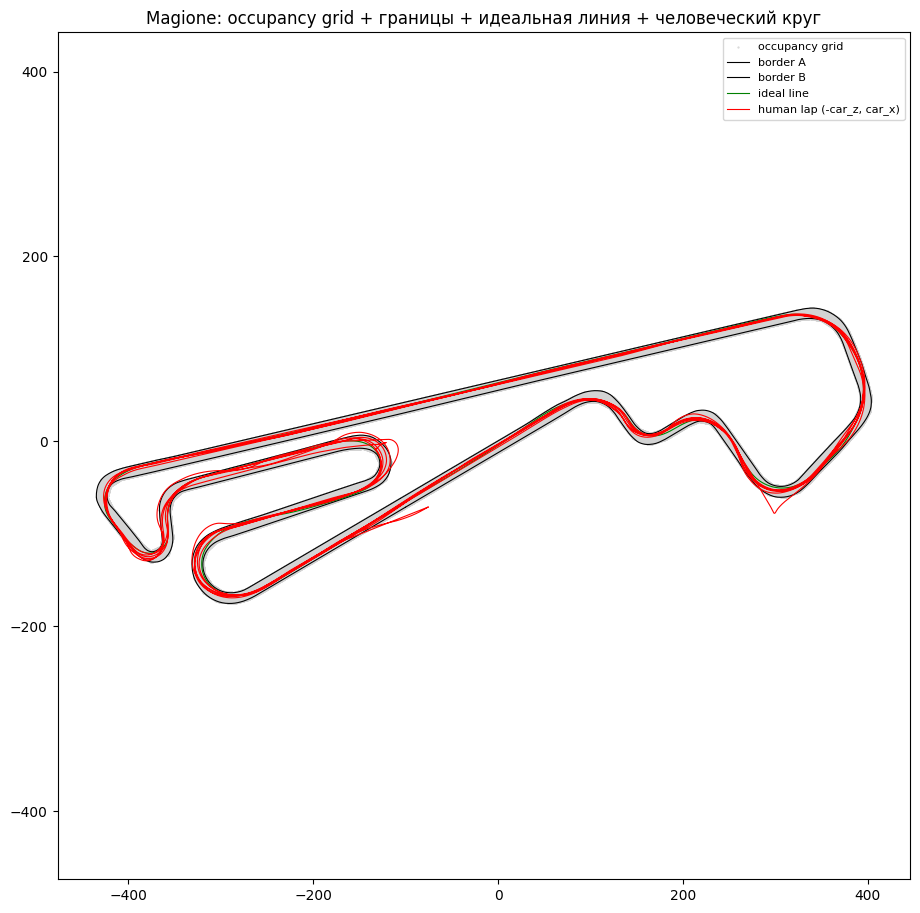

In [3]:
cell_size = grid["cell_size"]
x_range = np.arange(grid["min_x"], grid["max_x"], cell_size)
y_range = np.arange(grid["min_y"], grid["max_y"], cell_size)
xx, yy = np.meshgrid(x_range, y_range)
occupancy = grid["grid"].reshape(xx.shape)

traj_x = -lap["car_z"].values
traj_y = lap["car_x"].values

fig, ax = plt.subplots(figsize=(11, 11))
occ_y, occ_x = np.where(occupancy == 1)
ax.scatter(xx[occ_y[::3], occ_x[::3]], yy[occ_y[::3], occ_x[::3]], s=0.3, color="lightgray", label="occupancy grid")
ax.plot(track["left_border_x"], track["left_border_y"], color="black", lw=0.8, label="border A")
ax.plot(track["right_border_x"], track["right_border_y"], color="black", lw=0.8, label="border B")
ax.plot(racing_line["pos_x"], racing_line["pos_y"], color="green", lw=0.8, label="ideal line")
ax.plot(traj_x, traj_y, color="red", lw=0.8, label="human lap (-car_z, car_x)")
ax.axis("equal")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Magione: occupancy grid + границы + идеальная линия + человеческий круг")
plt.show()

## По кругам отдельно

Файл `lap_2026-05-27_13-23-37` - это цельная сессия, не один круг: в нём
7 кругов (`lap` 4-10). Общий график выше накладывает их все одной линией,
что маскирует, какой именно круг даёт отклонение у правой шпильки.
Разбиваем по `lap`, чтобы проверить границы для каждого круга отдельно, а
не только "в среднем по палитре".

4     2213
5     2090
6     1972
7     2018
8     2023
9     1916
10     119
Name: lap, dtype: int64


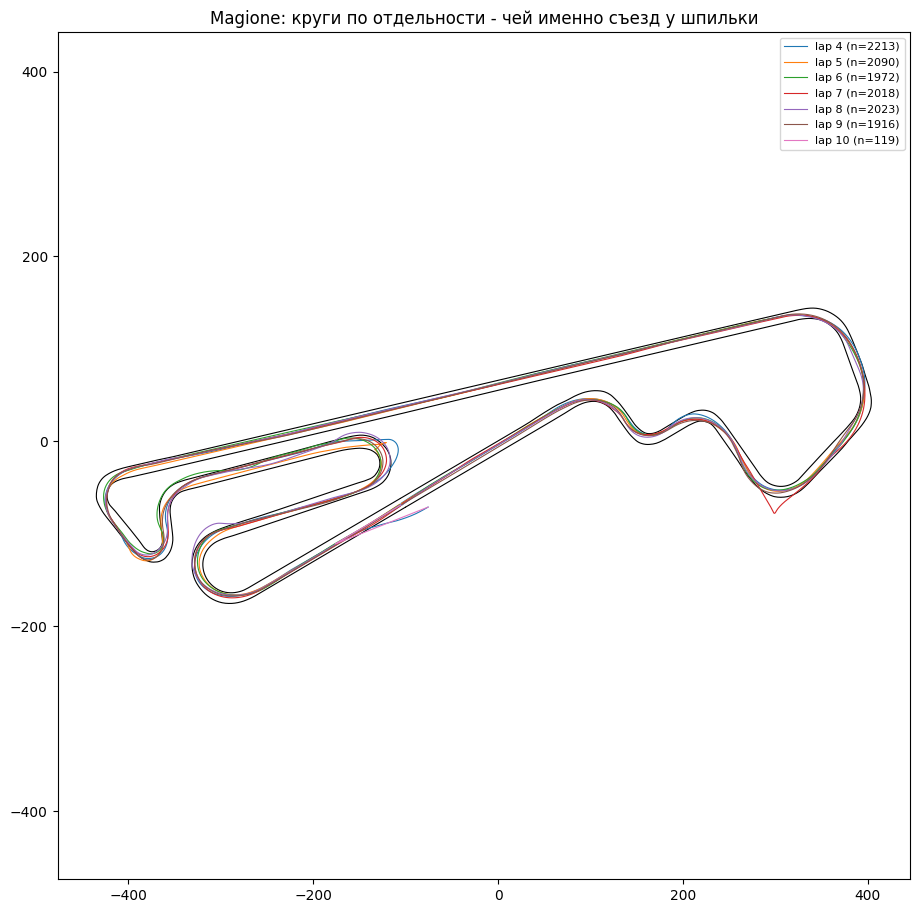

In [4]:
print(lap["lap"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(11, 11))
ax.plot(track["left_border_x"], track["left_border_y"], color="black", lw=0.8)
ax.plot(track["right_border_x"], track["right_border_y"], color="black", lw=0.8)

cmap = plt.get_cmap("tab10")
for i, lap_no in enumerate(sorted(lap["lap"].unique())):
    sub = lap[lap["lap"] == lap_no]
    ax.plot(-sub["car_z"], sub["car_x"], lw=0.8, color=cmap(i), label=f"lap {lap_no} (n={len(sub)})")

ax.axis("equal")
ax.legend(fontsize=8)
ax.set_title("Magione: круги по отдельности - чей именно съезд у шпильки")
plt.show()

**Готово когда:** траектория ложится внутрь границ по всему кругу -
подтверждено, и не только "в среднем": файл содержит 7 кругов (`lap`
4-10), по отдельности видно, что 6 из них (4, 5, 6, 8, 9, 10) идут внутри
границ на всей трассе, включая правую шпильку. Съезд там - **круг 7**,
чёткий одиночный выброс за границу у одного конкретного круга, а не
систематическая проблема системы координат или границ (остальные 6
кругов через тот же поворот проходят чисто). Круг 10 короткий (119 точек)
- вероятно, оборванный/неполный последний круг сессии.